<a href="https://colab.research.google.com/github/AlyssonBatista/Reader-and-grader-of-multiple-choice-tests./blob/main/Answer_Sheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install imutils

# Leitor e corretor de provas de múltipla escolha com cartão resposta usando reconhecimento óptico de marcação (OMR) em Python e OpenCV.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving fdfdfd.jpg to fdfdfd.jpg


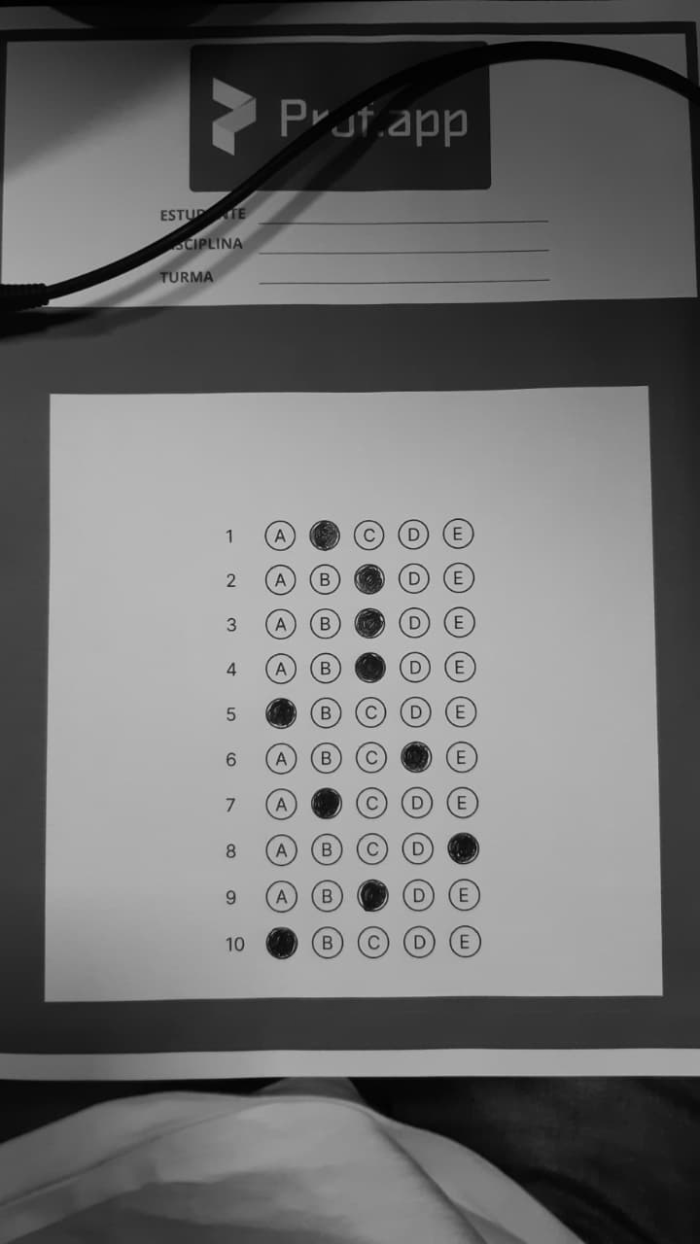

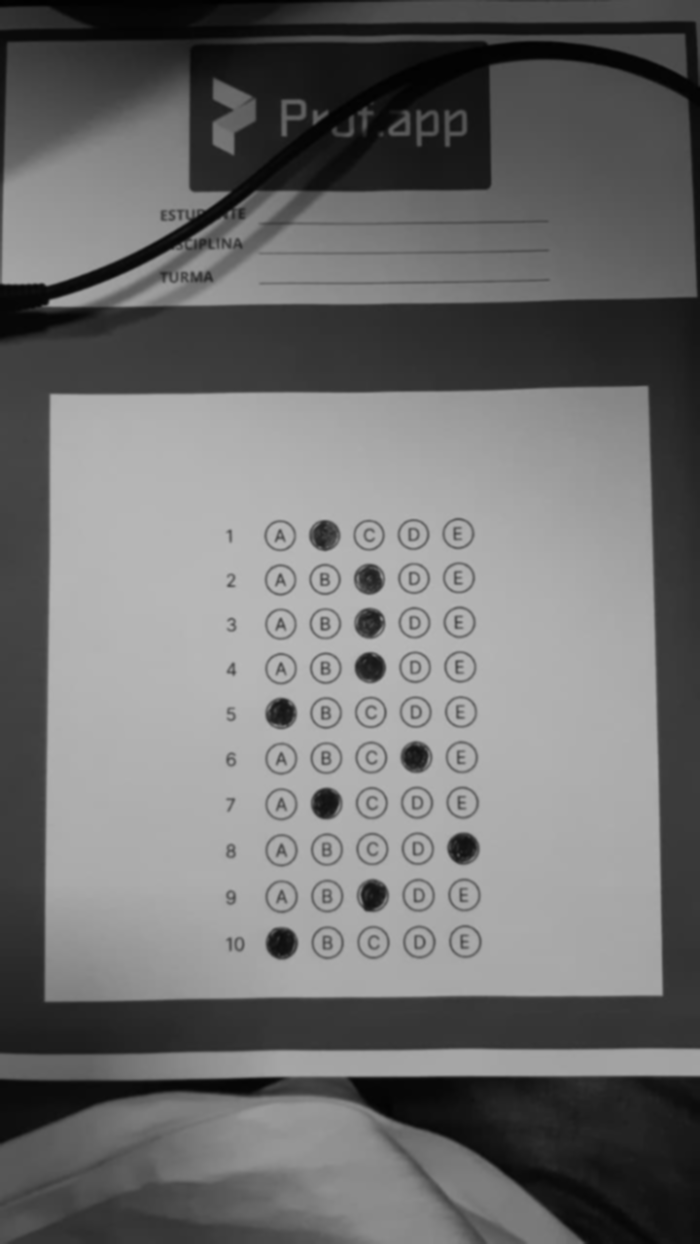

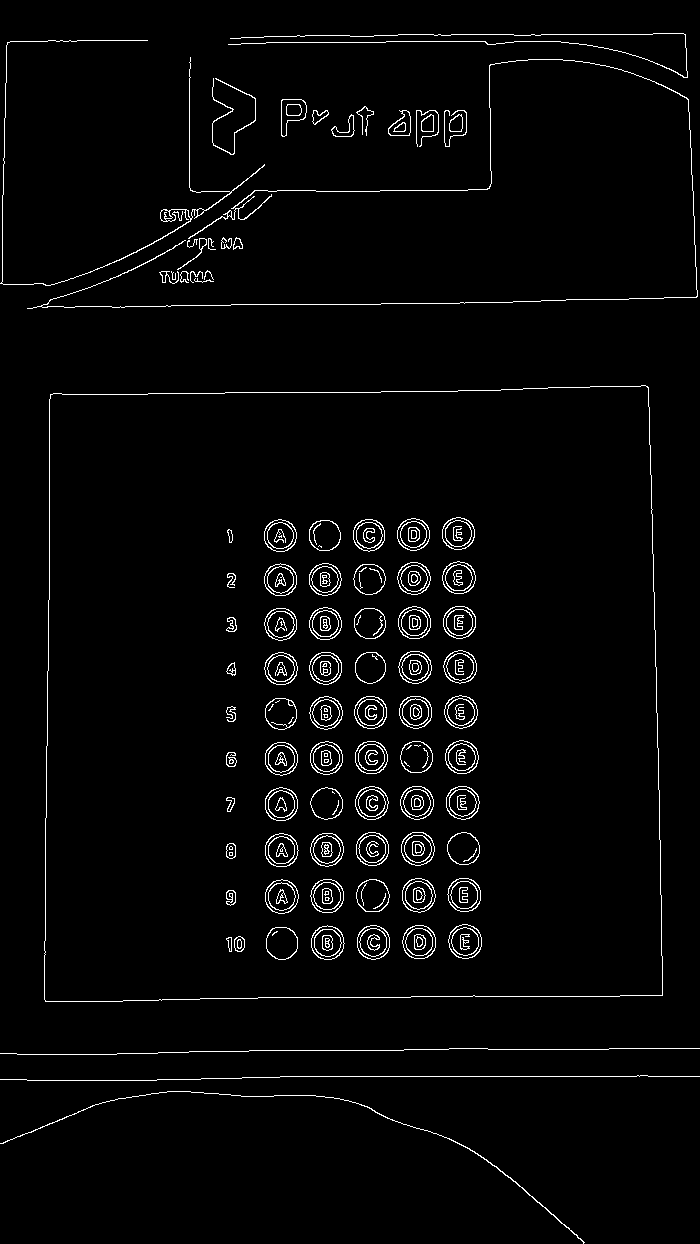

In [3]:
# ============================
# IMPORTAÇÕES NECESSÁRIAS
# ============================
# four_point_transform → utilizado mais tarde para "achatar" (retificar) o cartão de resposta
from imutils.perspective import four_point_transform
# contours → usado para ordenar contornos (da esquerda/direita, cima/baixo)
from imutils import contours
import numpy as np
import imutils
import cv2

# Biblioteca necessária para mostrar imagens no Google Colab
from google.colab.patches import cv2_imshow


# ============================
# CARREGAR A IMAGEM ENVIADA
# ============================
# "uploaded" é criado pelo comando files.upload() anteriormente no notebook.
# Ele guarda os arquivos enviados pelo usuário no Colab.
filename = list(uploaded.keys())[0]

# Carrega a imagem com OpenCV
# OBS: O OpenCV lê imagens no formato BGR (não RGB)
image = cv2.imread(filename)


# ============================
# PRÉ-PROCESSAMENTO INICIAL
# ============================
# Redimensiona a imagem para facilitar o processamento.
# Isso ajuda os algoritmos a rodarem mais rápido e com mais consistência.
image = imutils.resize(image, width=700)


# ----------------------------
# 1. Converter a imagem para escala de cinza
# ----------------------------
# Processar em tons de cinza deixa mais rápido e reduz ruído.
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ----------------------------
# 2. Aplicar desfoque (blur)
# ----------------------------
# Reduz detalhes desnecessários e facilita a detecção das bordas.
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# ----------------------------
# 3. Detectar bordas (Canny)
# ----------------------------
# Identifica contornos fortes, que ajudarão a encontrar o cartão resposta.
edged = cv2.Canny(blurred, 75, 200)


# ============================
# EXIBIR AS ETAPAS
# ============================
cv2_imshow(gray)     # imagem em escala de cinza
cv2_imshow(blurred)  # imagem borrada
cv2_imshow(edged)    # imagem com detecção de bordas


In [4]:
# ============================
# ENCONTRAR O CONTORNO DO CARTÃO-RESPOSTA
# ============================

# 1. Encontrar contornos na imagem de bordas (edged)
#    - cv2.RETR_EXTERNAL → pega apenas os contornos externos (mais limpo)
#    - cv2.CHAIN_APPROX_SIMPLE → reduz pontos desnecessários no contorno
cnts = cv2.findContours(
    edged.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# O OpenCV retorna diferentes quantidades dependendo da versão,
# imutils.grab_contours resolve isso automaticamente.
cnts = imutils.grab_contours(cnts)

# Ordena os contornos pelo tamanho da área (maiores primeiro)
# Isso funciona porque o cartão normalmente é o maior retângulo da imagem.
cnts = sorted(cnts, key=cv2.contourArea, reverse=True)


# Variável que irá guardar o contorno final do cartão
docCnt = None


# 2. Percorrer os contornos em ordem decrescente de área
for c in cnts:

    # Calcula o perímetro do contorno
    peri = cv2.arcLength(c, True)

    # Aproxima o contorno para uma forma mais simples usando
    # o algoritmo de Douglas-Peucker.
    # 0.02 * peri controla a precisão (ajusta o nível de "simplificação").
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)

    # 3. Identificar um contorno com *exatamente 4 pontos*
    #    Isso indica que provavelmente é um retângulo (o cartão).
    if len(approx) == 4:
        docCnt = approx
        break  # já encontramos o cartão, podemos parar


# Agora "docCnt" contém o contorno do cartão ou None se nada foi encontrado.



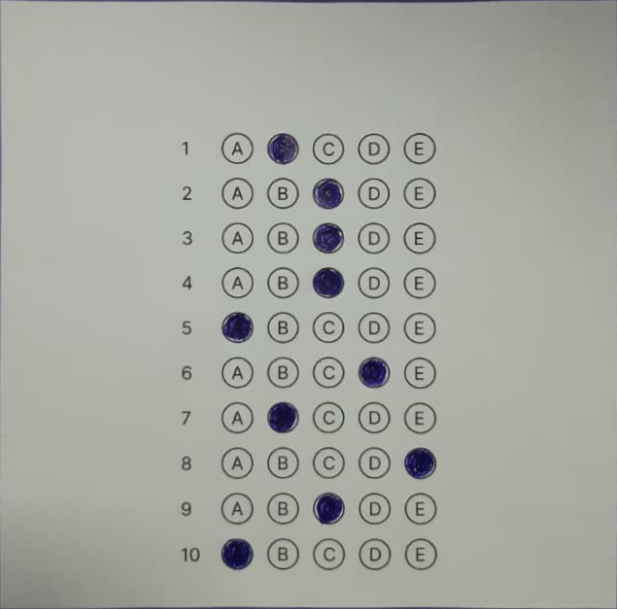

In [5]:
# ============================
# TRANSFORMAÇÃO DE PERSPECTIVA (RETIFICAR O CARTÃO)
# ============================

# O 'docCnt' contém os 4 pontos do cartão detectado.
# Aqui convertemos os pontos para uma matriz 4x2.
pts = docCnt.reshape(4, 2)

# "paper" = cartão retificado em QUALIDADE COLORIDA (BGR)
paper = four_point_transform(image, pts)

# "warped" = versão retificada em escala de cinza (útil para processamento)
warped = four_point_transform(gray, pts)

# Mostrar o cartão retificado
cv2_imshow(paper)


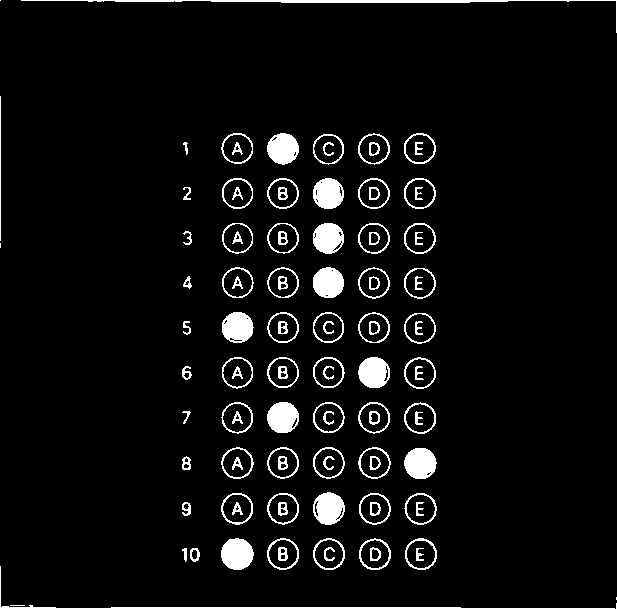

In [6]:
# ============================
# BINARIZAÇÃO (THRESHOLD) PARA DESTACAR BOLHAS
# ============================

# THRESH_BINARY_INV → bolhas ficam brancas
# OTSU → define o melhor valor de threshold automaticamente
thresh = cv2.threshold(
    warped,
    0,
    255,
    cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU
)[1]

# Mostrar imagem binarizada
cv2_imshow(thresh)



In [7]:
# ============================
# DETECÇÃO DAS BOLHAS DAS QUESTÕES
# ============================

# Encontrar contornos brancos na imagem binarizada
cnts = cv2.findContours(
    thresh.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
cnts = imutils.grab_contours(cnts)

questionCnts = []  # lista final com bolhas válidas

for c in cnts:
    # Obter a caixa delimitadora do contorno
    x, y, w, h = cv2.boundingRect(c)

    # Relação de aspecto → ajuda a garantir que é uma forma QUASE circular
    ar = w / float(h)

    # Filtros para garantir que o contorno é uma bolha
    # - tamanho mínimo (20x20 px)
    # - quase quadrado (ar entre 0.9 e 1.1)
    if w >= 20 and h >= 20 and 0.9 <= ar <= 1.1:
        questionCnts.append(c)

print("Bolhas detectadas:", len(questionCnts))


Bolhas detectadas: 50


In [8]:
# Ordena de cima para baixo para garantir que a leitura das questões fique correta
questionCnts = contours.sort_contours(questionCnts, method="top-to-bottom")[0]


In [9]:
# gabarito da prova

ANSWER_KEY_LETTERS = ["A","B","C","C","C","A","C","E","A","A","A","B","C","C","C","A","C","E","A","A"]
# ANSWER_KEY_LETTERS = ["A","B","C","C","C","A","C","E","A","A"]
# ANSWER_KEY_LETTERS = ["A","B","C","C","C"]
ANSWER_KEY = {i: "ABCDE".index(a) for i, a in enumerate(ANSWER_KEY_LETTERS)}

Detectadas 10 questões em 1 colunas
Questão 1: centro primeira bolha ~ x=237.0, y=148.5
Questão 2: centro primeira bolha ~ x=237.5, y=193.5
Questão 3: centro primeira bolha ~ x=237.5, y=238.5
Questão 4: centro primeira bolha ~ x=238.0, y=282.5
Questão 5: centro primeira bolha ~ x=238.0, y=327.5
Questão 6: centro primeira bolha ~ x=237.5, y=373.0
Questão 7: centro primeira bolha ~ x=237.0, y=418.0
Questão 8: centro primeira bolha ~ x=237.5, y=463.0
Questão 9: centro primeira bolha ~ x=237.0, y=509.0
Questão 10: centro primeira bolha ~ x=237.5, y=554.0

Total de acertos: 4

Alternativas corretas de cada questão: ['A', 'B', 'C', 'C', 'C', 'A', 'C', 'E', 'A', 'A', 'A', 'B', 'C', 'C', 'C', 'A', 'C', 'E', 'A', 'A']


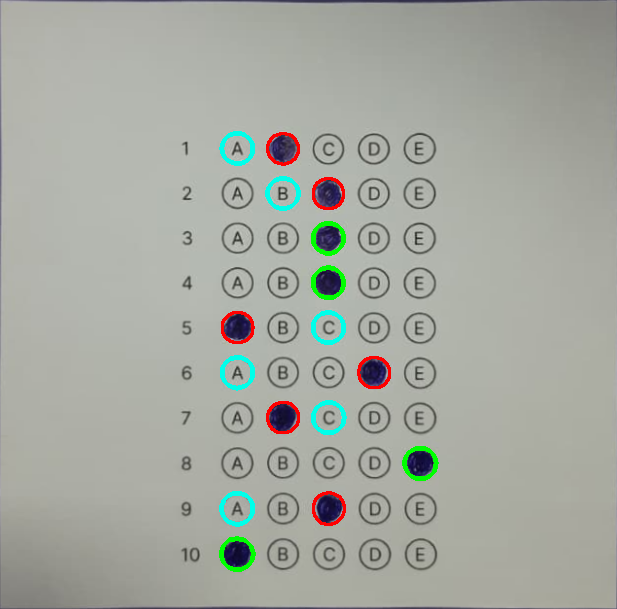

In [10]:
NUM_ALTERNATIVAS = 5

# -> Função auxiliar: retorna centro x,y de um contorno
def contour_center(c):
    (x, y, w, h) = cv2.boundingRect(c)
    return (x + w/2, y + h/2)

# 1) garantir que temos número inteiro de questões
n_bolhas = len(questionCnts)
if n_bolhas % NUM_ALTERNATIVAS != 0:
    raise ValueError(f"Quantidade de bolhas ({n_bolhas}) não é múltipla de {NUM_ALTERNATIVAS}")

n_questoes = n_bolhas // NUM_ALTERNATIVAS

# 2) decidir número de colunas esperado
expected_cols = 1 if n_questoes <= 10 else 2

# 3) clustering das colunas via 1D k-means simples
centers_x = [contour_center(c)[0] for c in questionCnts]
idxs = list(range(len(questionCnts)))

if expected_cols == 1:
    columns = [idxs]
else:
    xs = centers_x[:]
    c1 = min(xs)
    c2 = max(xs)
    for _ in range(20):
        cluster1 = []
        cluster2 = []
        for i, x in enumerate(xs):
            if abs(x - c1) < abs(x - c2):
                cluster1.append(i)
            else:
                cluster2.append(i)
        if len(cluster1) == 0 or len(cluster2) == 0:
            break
        new_c1 = sum(xs[i] for i in cluster1) / len(cluster1)
        new_c2 = sum(xs[i] for i in cluster2) / len(cluster2)
        if abs(new_c1 - c1) < 1e-3 and abs(new_c2 - c2) < 1e-3:
            break
        c1, c2 = new_c1, new_c2

    cluster1_idxs = cluster1
    cluster2_idxs = cluster2

    columns = [cluster1_idxs, cluster2_idxs]
    columns = [c for c in columns if len(c) > 0]

# 4) ordenar colunas esquerda → direita
col_info = []
for col in columns:
    mean_x = sum(centers_x[i] for i in col) / len(col)
    col_info.append((mean_x, col))
col_info.sort(key=lambda x: x[0])
columns_sorted = [c for (_, c) in col_info]

# 5) ordenar cada coluna top-bottom → agrupar → ordenar left-right
ordered_cnts = []
for col in columns_sorted:
    col_sorted_by_y = sorted(col, key=lambda i: contour_center(questionCnts[i])[1])

    if len(col_sorted_by_y) % NUM_ALTERNATIVAS != 0:
        print("Aviso: coluna não tem múltiplo de NUM_ALTERNATIVAS. Seguindo mesmo assim.")

    for start in range(0, len(col_sorted_by_y), NUM_ALTERNATIVAS):
        group_idxs = col_sorted_by_y[start:start + NUM_ALTERNATIVAS]
        group_sorted_lr = sorted(group_idxs, key=lambda i: contour_center(questionCnts[i])[0])
        for i in group_sorted_lr:
            ordered_cnts.append(questionCnts[i])

# 6) substituir lista original pela ordenada
questionCnts = ordered_cnts

# DEBUG
print(f"Detectadas {n_questoes} questões em {len(columns_sorted)} colunas")
for qi in range(0, len(questionCnts), NUM_ALTERNATIVAS):
    (cx, cy) = contour_center(questionCnts[qi])
    qnum = qi//NUM_ALTERNATIVAS + 1
    print(f"Questão {qnum}: centro primeira bolha ~ x={cx:.1f}, y={cy:.1f}")



# -------------------------------------------------------------
# -------------  AQUI ENTRA A LÓGICA DE CORREÇÃO  -------------
# -------------------------------------------------------------

correct = 0
respostas_aluno = []

for (q, i) in enumerate(range(0, len(questionCnts), NUM_ALTERNATIVAS)):

    # 5 bolhas de uma questão
    cnts = contours.sort_contours(questionCnts[i:i + NUM_ALTERNATIVAS])[0]
    pixel_counts = []

    for (j, c) in enumerate(cnts):
        mask = np.zeros(thresh.shape, dtype="uint8")
        cv2.drawContours(mask, [c], -1, 255, -1)
        mask = cv2.bitwise_and(thresh, thresh, mask=mask)
        total = cv2.countNonZero(mask)
        pixel_counts.append((total, j))

    pixel_counts.sort(reverse=True, key=lambda x: x[0])
    melhor = pixel_counts[0]
    segunda = pixel_counts[1]

    if segunda[0] > melhor[0] * 0.80:
        print(f"Questão {q+1}: múltiplas respostas → inválida")
        respostas_aluno.append(None)
        continue

    if melhor[0] < 100:
        print(f"Questão {q+1}: em branco")
        respostas_aluno.append(None)
        continue

    resposta_aluno = melhor[1]
    respostas_aluno.append(resposta_aluno)

    # gabarito
    k = ANSWER_KEY[q]

    # --- CORREÇÃO VISUAL ---
    if resposta_aluno == k:
        # aluno acertou → verde
        cv2.drawContours(paper, [cnts[k]], -1, (0, 255, 0), 3)
        correct += 1
    else:
        # aluno errou:
        # 1) pintar a correta → vermelho
        cv2.drawContours(paper, [cnts[k]], -1, (234, 255, 0), 3)

        # 2) opcional: pintar a alternativa marcada pelo aluno (azul)
        cv2.drawContours(paper, [cnts[resposta_aluno]], -1, (0, 0, 255), 2)


print("\nTotal de acertos:", correct)
print("\nAlternativas corretas de cada questão:", ANSWER_KEY_LETTERS)

cv2_imshow(paper)



In [11]:
# porcentagem de acertos
score = (correct / len(ANSWER_KEY)) * 100

print(f"Acertos: {correct}")
print(f"Nota final: {score:.2f}%")


Acertos: 4
Nota final: 20.00%


[INFO] score: 20.00%


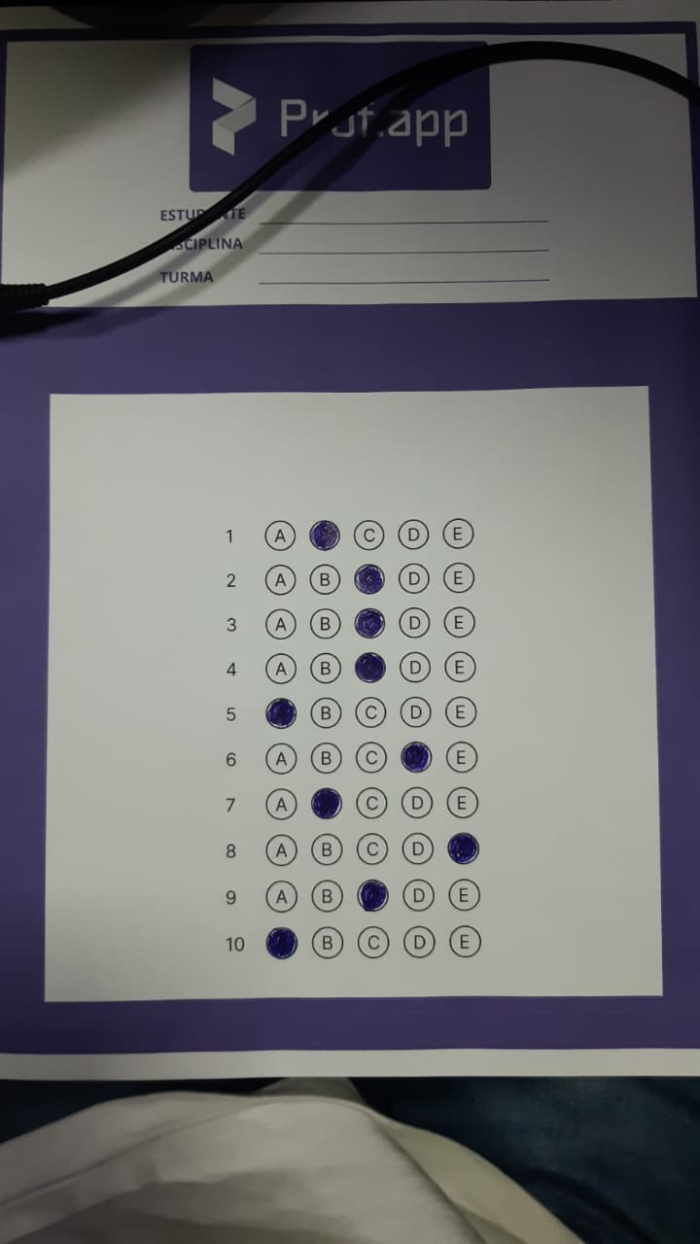

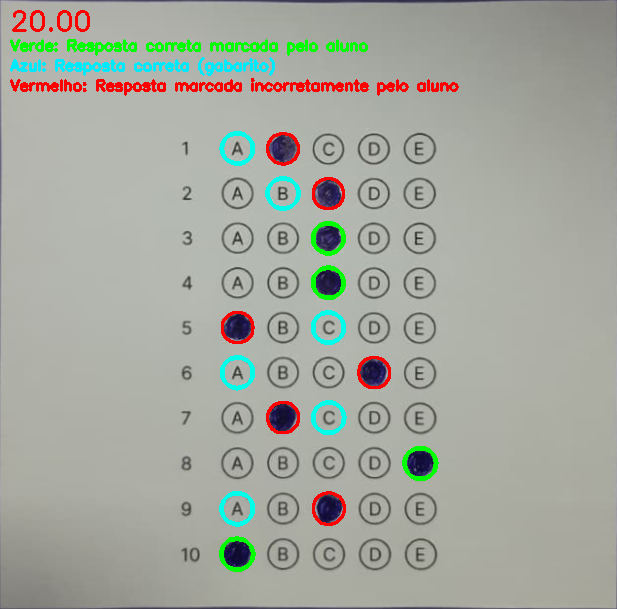

In [12]:
# calcular nota novamente (10 questões)
score = (correct / len(ANSWER_KEY)) * 100
print("[INFO] score: {:.2f}%".format(score))

# escreve a nota no canto superior da folha transformada
cv2.putText(
    paper,
    "{:.2f}".format(score),
    (10, 30),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.9,
    (0, 0, 255),
    2
)

# --- LEGENDA DAS CORES ---
# Verde = acerto
cv2.putText(
    paper,
    "Verde: Resposta correta marcada pelo aluno",
    (10, 50),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.5,
    (0, 255, 0),  # verde
    2
)

# Azul = gabarito
cv2.putText(
    paper,
    "Azul: Resposta correta (gabarito)",
    (10, 70),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.5,
    (255, 234, 0),  # azul utilizado por voce
    2
)

# Vermelho = erro
cv2.putText(
    paper,
    "Vermelho: Resposta marcada incorretamente pelo aluno",
    (10, 90),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.5,
    (0, 0, 255),  # vermelho
    2
)

# --- FIM LEGENDA ---

# mostra imagens finais
cv2_imshow(image)
cv2_imshow(paper)

